# Relative Valuation (상대가치 평가) v3
## DuPont 2yr 예측 기반 PER / PBR / PSR 이론적 적정주가

---
### v1 → v3 핵심 변경: ROE 구간별 g cap 차별화

**문제 (v1):** `g = clip(ROE * retention, 0, GDP=4%)` — 모든 기업에 동일한 4% cap 적용.
ROE 61%인 NFLX도 g=4%로 고정되어 Gordon 공식 내부 불일치 발생.

**해결 (v3):** ROE 구간별로 g cap을 차별화, Gordon 공식 내부 일관성 유지:

| ROE 구간 | g cap | 비고 |
|----------|-------|------|
| ROE < 15% | GDP (4%) | 저성장: 기존 동일 |
| 15% ≤ ROE < 30% | min(8%, Re×0.75) | 중성장: 8% 또는 Re 안전 마진 중 낮은 쪽 |
| ROE ≥ 30% | Re × 0.75 | 고성장: spread 최소 Re×25% 보장 |

Gordon 공식은 동일: `PBR = (ROE - g) / (Re - g)`  
Re×0.75 cap → spread = Re - g ≥ Re×0.25 (spread 붕괴 방지)

| Cell | 역할 |
|------|------|
| 1    | 경로 자동감지 (노트북/데스크탑) |
| 2    | Import & 상수 |
| 3    | DB 연결 & 테이블 초기화 |
| 4    | RelativeValModel 클래스 |
| 5    | 배치 실행 |
| 6    | 결과 조회 & 시각화 |


## Cell 1 · 경로 자동감지

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\\ubc14\ud0d1 \ud654\uba74\\investment\\investment_strategy",
]

# 실제 경로 (raw string으로 직접 지정)
_CANDIDATE_ROOTS = [
    "C:/Users/Hoyoung_Park/PyCharmMiscProject/stock_forecast",
    "C:/Users/82108/OneDrive/바탕 화면/investment/investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] 자동 감지: {root}")
            return root
    for candidate in _CANDIDATE_ROOTS:
        if os.path.isdir(candidate) and os.path.isdir(os.path.join(candidate, "DATA")):
            if candidate not in sys.path:
                sys.path.insert(0, candidate)
            print(f"[PATH] 후보 경로: {candidate}")
            return candidate
    raise EnvironmentError(
        "DATA 폴더를 찾을 수 없습니다. _CANDIDATE_ROOTS 를 수정하세요."
    )

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")
print(f"[확인] DATA 경로    : {os.path.join(_ROOT, 'DATA')}")


[PATH] 자동 감지: C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] DATA 경로    : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA


## Cell 2 · Import & 설정 상수

In [2]:
import gc, math, time, traceback, warnings
import requests
from datetime import datetime
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

from DATA.config import get_db_info, get_engine
from DATA.us_target_ticker_list_screened_20260411 import ticker_list as US_TICKER_LIST

def log(tag: str, msg: str):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ===== 설정 상수 =====
FMP_API_KEY  = "hT0gAk87j9xZx4PlBApvBqfVL5IahvgV"
FMP_BASE     = "https://financialmodelingprep.com/api/v3"
FMP_LIMIT    = 40
FMP_SLEEP    = 0.35

TABLE_SALES  = "us_revenue_forecast_data"
TABLE_RE     = "us_rim_spread_data"
TABLE_RESULT = "us_relative_valuation"  # v3: 동일 테이블, ON DUPLICATE KEY UPDATE 사용
DEFAULT_PORT = 3307

FORECAST_HORIZON = 8
MIN_HISTORY      = 12
OLS_MIN_R2       = 0.20
OLS_MIN_SAMPLES  = 12
WINSORIZE_LIMITS = (0.05, 0.95)
GDP_GROWTH       = 0.04

# ── v3: ROE 구간별 g cap 상수 ───────────────────────────────────────
# 고성장(ROE>=30%): g <= Re * G_CAP_RE_RATIO  (spread 최소 Re*(1-ratio) 보장)
# 중성장(ROE>=15%): g <= min(G_CAP_MID_FIXED, Re * G_CAP_RE_RATIO)
# 저성장(ROE< 15%): g <= GDP_GROWTH (기존과 동일)
ROE_MID_THRESHOLD  = 0.15   # 중성장 구간 시작
ROE_HIGH_THRESHOLD = 0.30   # 고성장 구간 시작
G_CAP_MID_FIXED    = 0.08   # 중성장 절대 상한 (8%)
G_CAP_RE_RATIO     = 0.75   # g <= Re * 0.75 (spread >= Re*25% 보장)

W_INDIVIDUAL = 0.60
W_SECTOR     = 0.40
RF           = 0.045
ERP          = 0.055
RE_FLOOR     = 0.07
RE_CAP       = 0.18
BETA_DELTA   = 0.20

# 제외 업종 (부동산/에너지/통신/금융/리츠/보험/해외/ETF)
EXCLUDE_SECTORS = {
    "Real Estate", "Energy", "Communication Services",
    "Financials", "Insurance", "REIT", "ETF", "Foreign", "Utilities",
}

SECTOR_MAP = {
    "Real Estate": "Real Estate", "Energy": "Energy",
    "Communication Services": "Communication Services",
    "Financials": "Financials", "Financial Services": "Financials",
    "Insurance": "Insurance", "Utilities": "Utilities",
    "Consumer Defensive": "Consumer Defensive",
    "Consumer Cyclical": "Consumer Cyclical",
    "Healthcare": "Healthcare", "Technology": "Technology",
    "Industrials": "Industrials", "Basic Materials": "Basic Materials",
    "Consumer Staples": "Consumer Defensive",
}

INDUSTRY_OVERRIDE = {
    "REIT": "REIT", "Real Estate Investment": "REIT",
    "ETF": "ETF", "Exchange Traded Fund": "ETF",
}

SECTOR_BETA = {
    "Technology": 1.25, "Healthcare": 0.85,
    "Consumer Cyclical": 1.05, "Consumer Defensive": 0.65,
    "Industrials": 1.00, "Basic Materials": 0.95,
    "Communication Services": 0.90, "Energy": 1.10,
    "Financials": 0.80, "Real Estate": 0.75, "REIT": 0.70,
    "Insurance": 0.85, "Utilities": 0.45,
    "ETF": 1.00, "Foreign": 1.10, "Unknown": 1.00,
}

TICKER_START = 0
TICKER_END   = 1000
# SKIP_DONE 동작 방식:
#   True  — done_tickers.txt에 있는 종목은 skip (배치 중단 후 재시작용)
#   False — done_tickers.txt 무시, 모든 종목 재계산 (날짜 변경 후 재실행 시 사용)
# ※ 날짜가 바뀐 새 실행에서는 반드시 False로 설정하거나 done_tickers.txt를 삭제하세요
SKIP_DONE    = False

CHECKPOINT_DIR = "_relval_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print(f"[OK] Import 완료 v3 | 대상 티커: {len(US_TICKER_LIST):,}개")
print(f"[설정] FORECAST_HORIZON={FORECAST_HORIZON}Q  GDP_GROWTH={GDP_GROWTH}")
print(f"[설정] Beta 앙상블: individual x{W_INDIVIDUAL} + sector x{W_SECTOR}")
print(f"[설정 v3] g cap — 저성장(ROE<{ROE_MID_THRESHOLD:.0%}): GDP={GDP_GROWTH:.0%} | "
         f"중성장(ROE<{ROE_HIGH_THRESHOLD:.0%}): min({G_CAP_MID_FIXED:.0%}, Re×{G_CAP_RE_RATIO}) | "
         f"고성장(ROE>={ROE_HIGH_THRESHOLD:.0%}): Re×{G_CAP_RE_RATIO}")
print(f"[설정] 제외 업종: {EXCLUDE_SECTORS}")


[OK] Import 완료 v3 | 대상 티커: 1,026개
[설정] FORECAST_HORIZON=8Q  GDP_GROWTH=0.04
[설정] Beta 앙상블: individual x0.6 + sector x0.4
[설정 v3] g cap — 저성장(ROE<15%): GDP=4% | 중성장(ROE<30%): min(8%, Re×0.75) | 고성장(ROE>=30%): Re×0.75
[설정] 제외 업종: {'Utilities', 'Insurance', 'Financials', 'Communication Services', 'REIT', 'Foreign', 'Real Estate', 'ETF', 'Energy'}


## Cell 3 · DB 연결 & 테이블 초기화

In [3]:
def get_conn():
    return pymysql.connect(
        host=db_info["host"], port=int(db_info.get("port", DEFAULT_PORT)),
        user=db_info["user"], password=db_info["password"],
        db=db_info.get("database", "investar"),
        charset="utf8mb4", autocommit=False,
        cursorclass=pymysql.cursors.DictCursor,
    )

CREATE_SQL = """
CREATE TABLE IF NOT EXISTS `us_relative_valuation` (
  `id`               BIGINT      NOT NULL AUTO_INCREMENT,
  `date`             DATE        NOT NULL COMMENT '예측 실행일',
  `ticker`           VARCHAR(20) NOT NULL,
  `sector`           VARCHAR(50)          COMMENT '업종',
  `is_excluded`      TINYINT(1)  DEFAULT 0 COMMENT '제외 업종 여부 1=제외',
  `sales_y1`         DOUBLE,  `sales_y2` DOUBLE,
  `npm_y1`           DOUBLE,  `npm_y2`   DOUBLE,
  `at_y1`            DOUBLE,  `at_y2`    DOUBLE,
  `fl_y1`            DOUBLE,  `fl_y2`    DOUBLE,
  `roe_y1`           DOUBLE,  `roe_y2`   DOUBLE,
  `ni_y2`            DOUBLE,  `bve_y2`   DOUBLE,
  `eps_y2`           DOUBLE,  `bps_y2`   DOUBLE,  `sps_y2` DOUBLE,
  `payout_ratio`     DOUBLE,  `g_est`    DOUBLE,
  `beta_raw`         DOUBLE,  `beta_blume` DOUBLE,
  `beta_sector`      DOUBLE,  `beta_ensemble` DOUBLE,
  `re_low`           DOUBLE,  `re_mid`   DOUBLE,  `re_high` DOUBLE,
  `pbr_theory`       DOUBLE,  `psr_theory` DOUBLE, `per_theory` DOUBLE,
  `tp_pbr`           DOUBLE,  `tp_psr`   DOUBLE,  `tp_per`  DOUBLE, `tp_avg` DOUBLE,
  `tp_pbr_low`       DOUBLE,  `tp_pbr_high` DOUBLE,
  `tp_psr_low`       DOUBLE,  `tp_psr_high` DOUBLE,
  `current_price`    DOUBLE,
  `upside_pbr`       DOUBLE,  `upside_psr` DOUBLE,
  `upside_per`       DOUBLE,  `upside_avg` DOUBLE,
  `actual_pbr`       DOUBLE,  `actual_psr` DOUBLE, `actual_per` DOUBLE,
  `created_at`       DATETIME DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`),
  INDEX idx_ticker   (`ticker`),
  INDEX idx_date     (`date`),
  INDEX idx_sector   (`sector`),
  INDEX idx_excluded (`is_excluded`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4;
"""
conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비: {TABLE_RESULT}")
finally:
    conn.close()

try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공 host={db_info.get('host')}:{db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

# ── done_tickers.txt 관리 유틸 ──────────────────────────────────────
# 새 날짜로 전체 재실행하려면 아래 코드를 실행하세요 (주석 해제)
# import glob
# for f in glob.glob(os.path.join(CHECKPOINT_DIR, "*.txt")):
#     os.remove(f)
#     print(f"[삭제] {f}")
# print("[완료] checkpoint 초기화 — 다음 배치 실행 시 전체 재계산됩니다")


[00:56:52][DB] 테이블 준비: us_relative_valuation
[00:56:52][DB] 연결 성공 host=192.168.0.230:3307


## Cell 4 · RelativeValModel 클래스

In [4]:
# RelativeValModel — 상대가치 평가 모델 v3
# DuPont 2yr 예측 -> PBR/PSR/PER 이론적 멀티플 -> 적정주가 -> 괴리율

class RelativeValModel:
    """
    상대가치 3종 적정주가 평가 (v3 — ROE 구간별 g cap 차별화).

    공식 (v1과 동일):
      PBR_theory = (ROE - g) / (Re - g)      [Gordon Growth]
      PSR_theory = (NPM × (1-payout)) / (Re - g)
      PER_theory = PBR / ROE

    v3 변경: g = clip(ROE*retention, 0, g_cap) — g_cap을 ROE 구간별 차별화
      저성장 ROE <  15%: g_cap = GDP (4%)
      중성장 ROE <  30%: g_cap = min(8%, Re×0.75)
      고성장 ROE >= 30%: g_cap = Re×0.75   (spread >= Re×25% 보장)
    """

    def __init__(self, ticker: str, engine, fmp_api_key: str = FMP_API_KEY,
                 verbose: bool = False):
        self.ticker   = ticker.upper()
        self.engine   = engine
        self.api_key  = fmp_api_key
        self.verbose  = verbose
        self._sales_actual   = None
        self._sales_forecast = None
        self._inc  = None
        self._bs   = None
        self._cf   = None
        self._sector      = "Unknown"
        self._is_excluded = False
        self.valuation    = None

    @staticmethod
    def _winsorize(s):
        lo, hi = s.quantile(WINSORIZE_LIMITS[0]), s.quantile(WINSORIZE_LIMITS[1])
        return s.clip(lo, hi)

    def _fmp_get(self, endpoint, period="quarter", limit=FMP_LIMIT):
        url = f"{FMP_BASE}/{endpoint}/{self.ticker}"
        for attempt in range(3):
            try:
                r = requests.get(url, params={"period":period,"limit":limit,
                                              "apikey":self.api_key}, timeout=12)
                if r.status_code == 429:
                    time.sleep(1.5 + attempt); continue
                r.raise_for_status()
                data = r.json()
                if isinstance(data, dict) and "Error Message" in data:
                    return pd.DataFrame()
                return pd.DataFrame(data) if isinstance(data, list) else pd.DataFrame()
            except Exception as e:
                if attempt == 2:
                    if self.verbose: log(self.ticker, f"FMP {endpoint} fail: {e}")
                    return pd.DataFrame()
                time.sleep(FMP_SLEEP + attempt * 0.5)
        return pd.DataFrame()

    def _parse_date_col(self, df):
        df = df.copy()
        df["report_date"] = pd.to_datetime(
            df.get("acceptedDate", df.get("fillingDate", pd.NaT)), errors="coerce")
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        def _qend(row):
            if pd.notna(row.get("report_date")):
                return (row["report_date"] - pd.Timedelta(days=45)).to_period("Q").to_timestamp("Q")
            return row["date"].to_period("Q").to_timestamp("Q")
        df["date"] = df.apply(_qend, axis=1)
        return df.sort_values("date").drop_duplicates("date", keep="last").reset_index(drop=True)

    def _n(self, val):
        """NaN/Inf -> None (MySQL NULL)."""
        if val is None: return None
        try:
            f = float(val)
            return None if (np.isnan(f) or np.isinf(f)) else f
        except (TypeError, ValueError):
            return val

    # --- 1. Sales 로드 ---
    def load_sales(self):
        conn_local = get_conn()
        try:
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT date, value FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='actual' ORDER BY date",
                    (self.ticker,))
                actual_rows = cur.fetchall()
            with conn_local.cursor() as cur:
                cur.execute(
                    f"SELECT MAX(forecast_date) AS max_fd FROM `{TABLE_SALES}` "
                    f"WHERE ticker=%s AND item='sale' AND data_type='forecast'",
                    (self.ticker,))
                row = cur.fetchone()
                max_fd = row["max_fd"] if row else None
            fc_rows = []
            if max_fd:
                with conn_local.cursor() as cur:
                    cur.execute(
                        f"SELECT date, model, value FROM `{TABLE_SALES}` "
                        f"WHERE ticker=%s AND item='sale' AND data_type='forecast' "
                        f"AND forecast_date=%s ORDER BY model, date",
                        (self.ticker, max_fd))
                    fc_rows = cur.fetchall()
        finally:
            conn_local.close()

        if not actual_rows:
            raise ValueError(f"[{self.ticker}] Sales 실적 없음")

        act_df = pd.DataFrame(actual_rows)
        act_df["date"]  = pd.to_datetime(act_df["date"])
        act_df["value"] = pd.to_numeric(act_df["value"], errors="coerce")
        actual = (act_df.sort_values("date").drop_duplicates("date", keep="last")
                        .set_index("date")["value"])

        if not fc_rows:
            raise ValueError(f"[{self.ticker}] Sales forecast 없음")

        fc_df = pd.DataFrame(fc_rows)
        fc_df["date"]  = pd.to_datetime(fc_df["date"])
        fc_df["value"] = pd.to_numeric(fc_df["value"], errors="coerce")

        priority = ["Ensemble","SARIMA","ETS","Theta"]
        available = fc_df["model"].unique().tolist()
        ordered   = [m for m in priority if m in available] +                     [m for m in available if m not in priority]

        forecast = pd.Series(dtype=float)
        for mn in ordered:
            fc = (fc_df[fc_df["model"]==mn].sort_values("date")
                     .drop_duplicates("date",keep="last")
                     .set_index("date")["value"].dropna())
            if len(fc) >= FORECAST_HORIZON:
                forecast = fc.iloc[:FORECAST_HORIZON]; break
            elif len(fc) > 0 and forecast.empty:
                forecast = fc

        if forecast.empty:
            raise ValueError(f"[{self.ticker}] forecast empty")

        if len(forecast) < FORECAST_HORIZON:
            extra_idx = pd.date_range(
                start=forecast.index[-1] + pd.offsets.QuarterEnd(1),
                periods=FORECAST_HORIZON - len(forecast), freq="QE")
            forecast = pd.concat([forecast,
                pd.Series([float(forecast.iloc[-1])]*len(extra_idx), index=extra_idx)])

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:FORECAST_HORIZON]
        if self.verbose:
            log(self.ticker, f"Sales actual={len(actual)}Q forecast={len(self._sales_forecast)}Q")
        return self

    # --- 2. 재무제표 ---
    def load_financials(self):
        time.sleep(FMP_SLEEP)
        inc = self._fmp_get("income-statement")
        time.sleep(FMP_SLEEP)
        bs  = self._fmp_get("balance-sheet-statement")
        time.sleep(FMP_SLEEP)
        cf  = self._fmp_get("cash-flow-statement")
        if inc.empty or bs.empty:
            raise ValueError(f"[{self.ticker}] IS/BS load failed")
        self._inc = self._parse_date_col(inc)
        self._bs  = self._parse_date_col(bs)
        self._cf  = self._parse_date_col(cf) if not cf.empty else None
        if self.verbose:
            cf_q = len(self._cf) if self._cf is not None else 0
            log(self.ticker, f"IS={len(self._inc)}Q BS={len(self._bs)}Q CF={cf_q}Q")
        return self

    # --- 3. 업종 분류 ---
    def load_sector(self):
        sector = "Unknown"; industry = ""
        try:
            r = requests.get(f"{FMP_BASE}/profile/{self.ticker}",
                             params={"apikey":self.api_key}, timeout=10)
            data = r.json()
            if isinstance(data, list) and data:
                p = data[0]
                sector   = p.get("sector","Unknown") or "Unknown"
                industry = p.get("industry","") or ""
                country  = p.get("country","US") or "US"
                if country not in ("US",""):
                    sector = "Foreign"
                if p.get("isEtf", False) or "ETF" in industry.upper():
                    sector = "ETF"
        except Exception:
            pass
        for kw, override in INDUSTRY_OVERRIDE.items():
            if kw.upper() in industry.upper():
                sector = override; break
        sector = SECTOR_MAP.get(sector, sector)
        self._sector      = sector
        self._is_excluded = sector in EXCLUDE_SECTORS
        if self.verbose:
            excl = " [EXCLUDED]" if self._is_excluded else ""
            log(self.ticker, f"sector={sector}{excl} industry={industry[:30]}")
        return self

    # --- 4. Beta & Re ---
    def estimate_beta_re(self):
        """Blume 조정 + 업종평균 앙상블 -> Re 3종 (low/mid/high)."""
        beta_raw = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/beta/{self.ticker}",
                             params={"period":"monthly","apikey":self.api_key}, timeout=8)
            d = r.json()
            if isinstance(d, list) and d:
                beta_raw = float(d[0].get("beta", np.nan) or np.nan)
            elif isinstance(d, dict):
                beta_raw = float(d.get("beta", np.nan) or np.nan)
        except Exception:
            pass
        if np.isnan(beta_raw) or abs(beta_raw) > 5:
            try:
                r2 = requests.get(f"{FMP_BASE}/key-metrics/{self.ticker}",
                                  params={"period":"annual","limit":1,"apikey":self.api_key},
                                  timeout=8)
                d2 = r2.json()
                if isinstance(d2, list) and d2:
                    b = float(d2[0].get("beta", np.nan) or np.nan)
                    if not np.isnan(b) and abs(b) < 5:
                        beta_raw = b
            except Exception:
                pass
        if np.isnan(beta_raw):
            beta_raw = SECTOR_BETA.get(self._sector, 1.0)

        beta_blume  = 0.67 * abs(beta_raw) + 0.33
        beta_sector = SECTOR_BETA.get(self._sector, 1.0)
        beta_ens    = W_INDIVIDUAL * beta_blume + W_SECTOR * beta_sector

        def _re(b):
            return float(np.clip(RF + b * ERP, RE_FLOOR, RE_CAP))
        re_mid  = _re(beta_ens)
        re_low  = _re(beta_ens - BETA_DELTA)
        re_high = _re(beta_ens + BETA_DELTA)

        result = {
            "beta_raw": beta_raw, "beta_blume": beta_blume,
            "beta_sector": beta_sector, "beta_ensemble": beta_ens,
            "re_low": re_low, "re_mid": re_mid, "re_high": re_high,
        }
        if self.verbose:
            log(self.ticker,
                f"Beta raw={beta_raw:.3f} blume={beta_blume:.3f} ens={beta_ens:.3f} "
                f"| Re low={re_low:.3%} mid={re_mid:.3%} high={re_high:.3%}")
        return result

    # --- 5. DuPont 2yr ---
    def estimate_dupont(self):
        """NPM/AT/FL -> ROE 2yr -> EPS/BPS/SPS (Year2 기준)."""
        inc = self._inc.copy(); bs = self._bs.copy(); cf = self._cf
        for col in ["revenue","netIncome","operatingIncome"]:
            if col not in inc.columns: inc[col] = np.nan
            inc[col] = pd.to_numeric(inc[col], errors="coerce")
        for col in ["totalAssets","totalStockholdersEquity"]:
            if col not in bs.columns: bs[col] = np.nan
            bs[col] = pd.to_numeric(bs[col], errors="coerce")

        # NPM
        df_npm = inc[["date","revenue","netIncome"]].dropna()
        df_npm = df_npm[df_npm["revenue"] > 0]
        npm_series = self._winsorize((df_npm["netIncome"]/df_npm["revenue"]).dropna())
        npm_median = float(npm_series.median()) if not npm_series.empty else 0.05
        npm_coef = npm_median
        if len(df_npm) >= OLS_MIN_SAMPLES:
            slope, _, r, _, _ = stats.linregress(df_npm["revenue"], df_npm["netIncome"])
            if r**2 >= OLS_MIN_R2:
                npm_coef = float(slope)

        # AT (TTM 기준)
        merged_at = inc[["date","revenue"]].merge(bs[["date","totalAssets"]], on="date", how="inner")
        merged_at = merged_at.dropna().sort_values("date").reset_index(drop=True)
        merged_at = merged_at[merged_at["totalAssets"] > 0]
        if len(merged_at) >= 4:
            merged_at["ttm"] = merged_at["revenue"].rolling(4).sum()
            atm = merged_at.dropna(subset=["ttm"])
            at_median = float(self._winsorize((atm["ttm"]/atm["totalAssets"]).dropna()).median())
        else:
            at_median = 0.70

        # FL
        bs_c = bs[["date","totalAssets","totalStockholdersEquity"]].dropna()
        bs_c = bs_c[(bs_c["totalAssets"]>0)&(bs_c["totalStockholdersEquity"]>0)]
        fl_median = float(np.clip(
            self._winsorize((bs_c["totalAssets"]/bs_c["totalStockholdersEquity"]).dropna()).median()
            if not bs_c.empty else 2.5, 1.0, 20.0))

        # Annual Sales 2yr
        fc_q = self._sales_forecast
        annual_sales = []
        for yr in range(0, min(len(fc_q),8), 4):
            annual_sales.append(float(fc_q.iloc[yr:yr+4].sum()))
        while len(annual_sales) < 2:
            annual_sales.append(annual_sales[-1] if annual_sales else 0)

        # BVE 시작값
        bve0 = float(bs.dropna(subset=["totalStockholdersEquity"])
                       ["totalStockholdersEquity"].iloc[-1])
        if bve0 <= 0: bve0 = 1e9

        # Shares
        shares = np.nan
        for col in ["weightedAverageShsOutDil","weightedAverageShsOut"]:
            if col in inc.columns:
                s = pd.to_numeric(inc[col].iloc[-1], errors="coerce")
                if pd.notna(s) and s > 0:
                    shares = float(s); break

        # Payout (배당+buyback)
        payout_med = 0.40
        ni_ser = pd.to_numeric(inc["netIncome"], errors="coerce")
        if cf is not None and not cf.empty:
            cashout = pd.Series(0.0, index=range(len(cf)))
            if "dividendsPaid" in cf.columns:
                cashout += pd.to_numeric(cf["dividendsPaid"], errors="coerce").abs().fillna(0).values
            for bk in ["commonStockRepurchased","repurchaseOfCommonStock"]:
                if bk in cf.columns:
                    cashout += pd.to_numeric(cf[bk], errors="coerce").abs().fillna(0).values; break
            merged_po = inc[["date"]].merge(
                cf[["date"]].assign(cashout=cashout.values), on="date", how="left")
            div_ser = merged_po["cashout"].fillna(0)
            po = (div_ser/ni_ser.abs()).replace([np.inf,-np.inf],np.nan)
            pr = po.iloc[-8:].dropna().clip(0, 3.0)
            if not pr.empty:
                payout_med = float(pr.median())

        # 2yr 루프
        results_yr = []
        bve = bve0
        for sales in annual_sales[:2]:
            ni  = npm_coef * sales
            npm = ni / sales if sales > 0 else 0.0
            roe = float(np.clip(npm * at_median * fl_median, -0.99, 3.0))
            retention = max(1.0 - payout_med, -0.5)
            bve_end = bve + ni * retention
            results_yr.append({"sales":sales,"ni":ni,"npm":npm,
                                "at":at_median,"fl":fl_median,"roe":roe,"bve":bve_end})
            bve = bve_end

        y1, y2 = results_yr[0], results_yr[1]
        eps_y2 = y2["ni"] /shares  if (not np.isnan(shares) and shares>0) else np.nan
        bps_y2 = y2["bve"]/shares  if (not np.isnan(shares) and shares>0) else np.nan
        sps_y2 = y2["sales"]/shares if (not np.isnan(shares) and shares>0) else np.nan
        # ── v3: ROE 구간별 g_cap (re 없이 보수적 상한 적용; 최종값은 compute_multiples에서 재계산)
        _roe_for_g = y2["roe"]
        _g_raw     = _roe_for_g * max(1.0 - payout_med, 0.0)
        if _roe_for_g >= ROE_HIGH_THRESHOLD:
            _g_cap_pre = G_CAP_MID_FIXED  # re 모르므로 임시 8% 상한
        elif _roe_for_g >= ROE_MID_THRESHOLD:
            _g_cap_pre = G_CAP_MID_FIXED
        else:
            _g_cap_pre = GDP_GROWTH
        g_est  = float(np.clip(_g_raw, 0.0, _g_cap_pre))

        if self.verbose:
            log(self.ticker,
                f"DuPont Y2 ROE={y2['roe']:.1%} NPM={y2['npm']:.1%} "
                f"AT={at_median:.2f} FL={fl_median:.1f} | "
                f"EPS=${eps_y2:.2f} BPS=${bps_y2:.2f} SPS=${sps_y2:.2f} g_pre={g_est:.2%}")
        return {
            "npm_y1":y1["npm"],"npm_y2":y2["npm"],
            "at_y1":y1["at"], "at_y2":y2["at"],
            "fl_y1":y1["fl"], "fl_y2":y2["fl"],
            "roe_y1":y1["roe"],"roe_y2":y2["roe"],
            "sales_y1":y1["sales"],"sales_y2":y2["sales"],
            "ni_y2":y2["ni"],"bve_y2":y2["bve"],
            "eps_y2":eps_y2,"bps_y2":bps_y2,"sps_y2":sps_y2,
            "payout_ratio":payout_med,"g_est":g_est,"shares":shares,
        }

    # --- 6. 이론적 멀티플 ---
    def compute_multiples(self, dupont, beta_re):
        """
        PBR_theory = (ROE - g) / (Re - g)      [Gordon Growth, v3 g cap 차별화]
        PSR_theory = (NPM × (1-payout)) / (Re - g)
        PER_theory = PBR / ROE
        적정가 = Multiple x 실제지표_forecast
        """
        roe = dupont["roe_y2"]; npm = dupont["npm_y2"]
        payout = dupont["payout_ratio"]
        eps = dupont["eps_y2"]; bps = dupont["bps_y2"]; sps = dupont["sps_y2"]
        re_mid = beta_re["re_mid"]; re_low = beta_re["re_low"]; re_high = beta_re["re_high"]

        def _calc_g(re: float) -> float:
            """ROE 구간별 g cap 적용 — spread 안전성 보장."""
            retention = max(1.0 - payout, 0.0)
            g_raw = roe * retention
            if roe >= ROE_HIGH_THRESHOLD:          # 고성장: Re×0.75 cap
                g_cap = re * G_CAP_RE_RATIO
            elif roe >= ROE_MID_THRESHOLD:         # 중성장: min(8%, Re×0.75)
                g_cap = min(G_CAP_MID_FIXED, re * G_CAP_RE_RATIO)
            else:                                  # 저성장: GDP(4%) cap
                g_cap = GDP_GROWTH
            return float(np.clip(g_raw, 0.0, g_cap))

        def _mult(re):
            g = _calc_g(re)
            sp = max(re - g, 0.005)
            pbr = float(np.clip((roe - g)/sp, 0.1, 100.0)) if roe > g else 0.1
            psr = float(np.clip((max(npm,0)*(1-payout))/sp, 0.01, 50.0))
            per = float(np.clip(pbr/roe, 1.0, 200.0)) if roe > 0 else np.nan
            return pbr, psr, per, g

        pbr_m, psr_m, per_m, g_mid = _mult(re_mid)
        pbr_l, psr_l, _,     _     = _mult(re_low)
        pbr_h, psr_h, _,     _     = _mult(re_high)

        def _tp(mult, base):
            if np.isnan(base) or base<=0 or np.isnan(mult): return np.nan
            return float(mult * base)

        tp_pbr = _tp(pbr_m, bps); tp_psr = _tp(psr_m, sps); tp_per = _tp(per_m, eps)
        tp_pbr_low = _tp(pbr_l, bps); tp_pbr_hi = _tp(pbr_h, bps)
        tp_psr_low = _tp(psr_l, sps); tp_psr_hi = _tp(psr_h, sps)

        valid = [x for x in [tp_pbr,tp_psr,tp_per] if not np.isnan(x) and x>0]
        tp_avg = float(np.mean(valid)) if valid else np.nan

        cp = np.nan
        try:
            r = requests.get(f"{FMP_BASE}/quote/{self.ticker}",
                             params={"apikey":self.api_key}, timeout=8)
            qd = r.json()
            if isinstance(qd,list) and qd:
                cp = float(qd[0].get("price", np.nan) or np.nan)
        except Exception:
            pass

        def _up(tp):
            return (tp/cp-1)*100 if (not np.isnan(tp) and not np.isnan(cp) and cp>0) else np.nan

        actual_pbr = float(cp/bps) if (not np.isnan(cp) and not np.isnan(bps) and bps>0) else np.nan
        actual_psr = float(cp/sps) if (not np.isnan(cp) and not np.isnan(sps) and sps>0) else np.nan
        actual_per = float(cp/eps) if (not np.isnan(cp) and not np.isnan(eps) and eps>0) else np.nan

        if self.verbose:
            log(self.ticker,
                f"[v3] g={g_mid:.2%} PBR={pbr_m:.2f}x PSR={psr_m:.2f}x PER={per_m:.1f}x | "
                f"TP_avg=${tp_avg:.2f} Up={_up(tp_avg):.1f}% CP=${cp:.2f}")
        return {
            "pbr_theory":pbr_m,"psr_theory":psr_m,"per_theory":per_m,
            "tp_pbr":tp_pbr,"tp_psr":tp_psr,"tp_per":tp_per,"tp_avg":tp_avg,
            "tp_pbr_low":tp_pbr_low,"tp_pbr_high":tp_pbr_hi,
            "tp_psr_low":tp_psr_low,"tp_psr_high":tp_psr_hi,
            "current_price":cp,
            "upside_pbr":_up(tp_pbr),"upside_psr":_up(tp_psr),
            "upside_per":_up(tp_per),"upside_avg":_up(tp_avg),
            "actual_pbr":actual_pbr,"actual_psr":actual_psr,"actual_per":actual_per,
        }

    # --- 7. DB 저장 (1건씩 즉시 commit) ---
    def save_to_db(self, run_date=None):
        """
        메모리 관리 판단: 1건씩 즉시 commit 채택.
        20개 묶음 batch vs 1건씩 비교:
          - 1건씩: 처리 즉시 rows 메모리 해제, 중간 크래시 시 손실 0
          - 20개 묶음: 20개 누적 후 commit, 실패시 20개 손실, 메모리 더 사용
          -> 2000개 장시간 배치에서 1건씩 방식이 안전성+메모리 모두 유리
        """
        if self.valuation is None: return False
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation; n = self._n
        row = {
            "date":run_date,"ticker":self.ticker,
            "sector":self._sector,"is_excluded":1 if self._is_excluded else 0,
            "sales_y1":n(v.get("sales_y1")),"sales_y2":n(v.get("sales_y2")),
            "npm_y1":n(v.get("npm_y1")),"npm_y2":n(v.get("npm_y2")),
            "at_y1":n(v.get("at_y1")),"at_y2":n(v.get("at_y2")),
            "fl_y1":n(v.get("fl_y1")),"fl_y2":n(v.get("fl_y2")),
            "roe_y1":n(v.get("roe_y1")),"roe_y2":n(v.get("roe_y2")),
            "ni_y2":n(v.get("ni_y2")),"bve_y2":n(v.get("bve_y2")),
            "eps_y2":n(v.get("eps_y2")),"bps_y2":n(v.get("bps_y2")),"sps_y2":n(v.get("sps_y2")),
            "payout_ratio":n(v.get("payout_ratio")),"g_est":n(v.get("g_est")),
            "beta_raw":n(v.get("beta_raw")),"beta_blume":n(v.get("beta_blume")),
            "beta_sector":n(v.get("beta_sector")),"beta_ensemble":n(v.get("beta_ensemble")),
            "re_low":n(v.get("re_low")),"re_mid":n(v.get("re_mid")),"re_high":n(v.get("re_high")),
            "pbr_theory":n(v.get("pbr_theory")),"psr_theory":n(v.get("psr_theory")),
            "per_theory":n(v.get("per_theory")),
            "tp_pbr":n(v.get("tp_pbr")),"tp_psr":n(v.get("tp_psr")),
            "tp_per":n(v.get("tp_per")),"tp_avg":n(v.get("tp_avg")),
            "tp_pbr_low":n(v.get("tp_pbr_low")),"tp_pbr_high":n(v.get("tp_pbr_high")),
            "tp_psr_low":n(v.get("tp_psr_low")),"tp_psr_high":n(v.get("tp_psr_high")),
            "current_price":n(v.get("current_price")),
            "upside_pbr":n(v.get("upside_pbr")),"upside_psr":n(v.get("upside_psr")),
            "upside_per":n(v.get("upside_per")),"upside_avg":n(v.get("upside_avg")),
            "actual_pbr":n(v.get("actual_pbr")),"actual_psr":n(v.get("actual_psr")),
            "actual_per":n(v.get("actual_per")),
        }
        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date,ticker,sector,is_excluded,
             sales_y1,sales_y2,npm_y1,npm_y2,at_y1,at_y2,fl_y1,fl_y2,
             roe_y1,roe_y2,ni_y2,bve_y2,eps_y2,bps_y2,sps_y2,
             payout_ratio,g_est,
             beta_raw,beta_blume,beta_sector,beta_ensemble,
             re_low,re_mid,re_high,
             pbr_theory,psr_theory,per_theory,
             tp_pbr,tp_psr,tp_per,tp_avg,
             tp_pbr_low,tp_pbr_high,tp_psr_low,tp_psr_high,
             current_price,upside_pbr,upside_psr,upside_per,upside_avg,
             actual_pbr,actual_psr,actual_per)
            VALUES
            (%(date)s,%(ticker)s,%(sector)s,%(is_excluded)s,
             %(sales_y1)s,%(sales_y2)s,%(npm_y1)s,%(npm_y2)s,
             %(at_y1)s,%(at_y2)s,%(fl_y1)s,%(fl_y2)s,
             %(roe_y1)s,%(roe_y2)s,%(ni_y2)s,%(bve_y2)s,
             %(eps_y2)s,%(bps_y2)s,%(sps_y2)s,
             %(payout_ratio)s,%(g_est)s,
             %(beta_raw)s,%(beta_blume)s,%(beta_sector)s,%(beta_ensemble)s,
             %(re_low)s,%(re_mid)s,%(re_high)s,
             %(pbr_theory)s,%(psr_theory)s,%(per_theory)s,
             %(tp_pbr)s,%(tp_psr)s,%(tp_per)s,%(tp_avg)s,
             %(tp_pbr_low)s,%(tp_pbr_high)s,%(tp_psr_low)s,%(tp_psr_high)s,
             %(current_price)s,%(upside_pbr)s,%(upside_psr)s,
             %(upside_per)s,%(upside_avg)s,
             %(actual_pbr)s,%(actual_psr)s,%(actual_per)s)
            ON DUPLICATE KEY UPDATE
                tp_pbr=VALUES(tp_pbr),tp_psr=VALUES(tp_psr),
                tp_per=VALUES(tp_per),tp_avg=VALUES(tp_avg),
                upside_avg=VALUES(upside_avg),sector=VALUES(sector),
                roe_y2=VALUES(roe_y2),current_price=VALUES(current_price)
        """
        conn = get_conn()
        try:
            with conn.cursor() as cur:
                cur.execute(sql, row)
            conn.commit()
            return True
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()

    # --- 8. 전체 실행 ---
    def run(self):
        self.load_sales()
        self.load_financials()
        self.load_sector()
        beta_re = self.estimate_beta_re()
        dupont  = self.estimate_dupont()
        mults   = self.compute_multiples(dupont, beta_re)
        self.valuation = {**dupont, **beta_re, **mults}
        if self.verbose:
            v = self.valuation
            log(self.ticker,
                f"[v3] ROE_y2={v['roe_y2']:.1%} Re_mid={v['re_mid']:.3%} | "
                f"PBR={v['pbr_theory']:.2f}x PSR={v['psr_theory']:.2f}x | "
                f"TP_avg=${v['tp_avg']:.2f} Up={v['upside_avg']:.1f}%")
        return self


def process_one_ticker_rv(ticker, engine, verbose=False, run_date=None, save_db=True):
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        model = RelativeValModel(ticker=ticker, engine=engine, verbose=verbose)
        model.run()
        saved = model.save_to_db(run_date) if save_db else False
        v = model.valuation
        return {
            "status":"ok","ticker":ticker,
            "sector":model._sector,"excluded":model._is_excluded,
            "tp_pbr":v.get("tp_pbr",np.nan),"tp_psr":v.get("tp_psr",np.nan),
            "tp_per":v.get("tp_per",np.nan),"tp_avg":v.get("tp_avg",np.nan),
            "upside_avg":v.get("upside_avg",np.nan),
            "roe_y2":v.get("roe_y2",np.nan),"re_mid":v.get("re_mid",np.nan),
            "saved":saved,
        }
    except Exception as e:
        return {
            "status":"fail","ticker":ticker,"sector":"?","excluded":False,
            "tp_pbr":np.nan,"tp_psr":np.nan,"tp_per":np.nan,"tp_avg":np.nan,
            "upside_avg":np.nan,"roe_y2":np.nan,"re_mid":np.nan,
            "saved":False,"msg":str(e)[:150],
        }
    finally:
        gc.collect()


print("[OK] RelativeValModel v3 정의 완료")
print(f"     저성장 g_cap=GDP({GDP_GROWTH:.0%}) | 중성장 g_cap=min({G_CAP_MID_FIXED:.0%}, Re×{G_CAP_RE_RATIO}) | "
      f"고성장 g_cap=Re×{G_CAP_RE_RATIO}")

# 단일 테스트 — 저성장/고성장/초고성장 각 1개
for TEST_TICKER in ["JNJ", "NFLX", "NVDA", "MSFT", "WMT", "KLAC", "AMAT", "LRCX", "MU", "LLY"]:
    print(f"\n[Test] {TEST_TICKER} ...")
    _res = process_one_ticker_rv(TEST_TICKER, engine, verbose=True)
    print(f"  status={_res['status']}  sector={_res['sector']}  excluded={_res['excluded']}")
    if _res["status"] == "ok":
        print(f"  TP_PBR=${_res['tp_pbr']:.2f}  TP_PSR=${_res['tp_psr']:.2f}  TP_avg=${_res['tp_avg']:.2f}")
        print(f"  Upside_avg={_res['upside_avg']:.1f}%")


[OK] RelativeValModel v3 정의 완료
     저성장 g_cap=GDP(4%) | 중성장 g_cap=min(8%, Re×0.75) | 고성장 g_cap=Re×0.75

[Test] JNJ ...
[00:56:56][JNJ] Sales actual=65Q forecast=8Q
[00:56:59][JNJ] IS=32Q BS=32Q CF=32Q
[00:57:00][JNJ] sector=Healthcare industry=Drug Manufacturers - General
[00:57:01][JNJ] Beta raw=0.850 blume=0.899 ens=0.880 | Re low=8.238% mid=9.338% high=10.438%
[00:57:01][JNJ] DuPont Y2 ROE=25.8% NPM=21.2% AT=0.49 FL=2.5 | EPS=$8.58 BPS=$36.69 SPS=$40.51 g_pre=4.93%
[00:57:02][JNJ] [v3] g=4.93% PBR=4.74x PSR=0.92x PER=18.4x | TP_avg=$122.92 Up=-48.5% CP=$238.46
[00:57:02][JNJ] [v3] ROE_y2=25.8% Re_mid=9.338% | PBR=4.74x PSR=0.92x | TP_avg=$122.92 Up=-48.5%
  status=ok  sector=Healthcare  excluded=False
  TP_PBR=$174.03  TP_PSR=$37.20  TP_avg=$122.92
  Upside_avg=-48.5%

[Test] NFLX ...
[00:57:02][NFLX] Sales actual=44Q forecast=8Q
[00:57:06][NFLX] IS=40Q BS=40Q CF=40Q
[00:57:07][NFLX] sector=Communication Services [EXCLUDED] industry=Entertainment
[00:57:08][NFLX] Beta raw=0.900 blum

2## Cell 5 · 배치 실행

In [5]:
# ─────────────────────────────────────────────────────────────────
# 배치 실행
# 메모리 관리: 1건씩 즉시 commit + gc.collect()
# SKIP_DONE=True: checkpoint에서 재시작 가능
# ─────────────────────────────────────────────────────────────────

RUN_TICKERS = US_TICKER_LIST[TICKER_START:TICKER_END]
total    = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

# ── done_set: "ticker|날짜" 형식으로 저장 → 같은 날짜만 skip
# 날짜가 바뀌면 done_set에 해당 항목이 없으므로 자동으로 재계산됨
done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            # 구형 포맷(ticker만) 과 신형 포맷(ticker|date) 모두 호환
            parts = line.split("|")
            if len(parts) == 2 and parts[1] == run_date:
                done_set.add(parts[0])   # 오늘 날짜로 완료된 것만 skip
            # 구형 포맷이면 날짜 모르므로 skip하지 않음 (재계산)

ok_cnt = skip_cnt = fail_cnt = excl_cnt = 0
results = []
t0 = time.time()

log("BATCH", f"시작: {total:,}개  run_date={run_date}  SKIP_DONE={SKIP_DONE}  "
             f"오늘 완료분(skip 대상)={len(done_set)}개")
print("=" * 70)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct    = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP", flush=True); skip_cnt += 1; continue

    res = process_one_ticker_rv(ticker, engine, verbose=False,
                                run_date=run_date, save_db=True)
    results.append(res)

    if res["status"] == "ok":
        excl_flag = " [EXCL]" if res["excluded"] else ""
        tp_s  = f"TP=${res['tp_avg']:.2f}" if not np.isnan(res["tp_avg"]) else "TP=N/A"
        up_s  = f"Up={res['upside_avg']:.1f}%" if not np.isnan(res["upside_avg"]) else ""
        print(f"{prefix} OK  {tp_s} {up_s}  Re={res['re_mid']:.3f}  "
              f"sec={res['sector'][:12]}{excl_flag}", flush=True)
        # 신형 포맷: ticker|날짜 로 저장
        with open(DONE_PATH, "a") as f:
            f.write(f"{ticker}|{run_date}\n")
        ok_cnt += 1
        if res["excluded"]: excl_cnt += 1
    else:
        print(f"{prefix} FAIL  {res.get('msg','')}", flush=True)
        with open(FAIL_PATH, "a") as f:
            f.write(f"{ticker}|{run_date}\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 70)
log("BATCH", f"완료  OK={ok_cnt}(제외포함{excl_cnt})  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# 결과 요약 (제외 업종 분리)
if results:
    df_all = pd.DataFrame(results)
    df_ok  = df_all[df_all["status"] == "ok"]
    df_incl = df_ok[~df_ok["excluded"]].sort_values("upside_avg", ascending=False)
    df_excl = df_ok[df_ok["excluded"]].sort_values("upside_avg", ascending=False)

    print(f"\n[포함 업종 TOP 20 — upside_avg 기준]")
    display(df_incl[["ticker","sector","tp_pbr","tp_psr","tp_per",
                      "tp_avg","upside_avg","roe_y2","re_mid"]].head(20))

    print(f"\n[제외 업종 목록 (통계 제외)]")
    display(df_excl[["ticker","sector","tp_avg","upside_avg"]].head(20))

    print(f"\n[업종 분포]")
    display(df_ok["sector"].value_counts())


[00:58:29][BATCH] 시작: 1,000개  run_date=2026-04-13  SKIP_DONE=False  오늘 완료분(skip 대상)=0개
[    1/1000] (  0.1%) NVDA     OK  TP=$353.38 Up=87.3%  Re=0.111  sec=Technology
[    2/1000] (  0.2%) GOOG     OK  TP=$371.53 Up=17.7%  Re=0.096  sec=Communicatio [EXCL]
[    3/1000] (  0.3%) AAPL     OK  TP=$51.37 Up=-80.3%  Re=0.111  sec=Technology
[    4/1000] (  0.4%) MSFT     OK  TP=$806.26 Up=117.4%  Re=0.111  sec=Technology
[    5/1000] (  0.5%) AMZN     OK  TP=$442.29 Up=85.5%  Re=0.102  sec=Consumer Cyc
[    6/1000] (  0.6%) META     OK  TP=$730.06 Up=15.9%  Re=0.096  sec=Communicatio [EXCL]
[    7/1000] (  0.7%) AVGO     OK  TP=$37.59 Up=-89.9%  Re=0.111  sec=Technology
[    8/1000] (  0.8%) TSLA     OK  TP=$161.28 Up=-53.8%  Re=0.102  sec=Consumer Cyc
[    9/1000] (  0.9%) LLY      OK  TP=$1902.16 Up=102.5%  Re=0.093  sec=Healthcare
[   10/1000] (  1.0%) WMT      OK  TP=$73.79 Up=-41.8%  Re=0.085  sec=Consumer Def
[   11/1000] (  1.1%) JNJ      OK  TP=$122.92 Up=-48.5%  Re=0.093  sec=Heal

,ticker,sector,tp_pbr,tp_psr,tp_per,tp_avg,upside_avg,roe_y2,re_mid
211,NETE,Technology,25050.081877,NaN,NaN,25050.081877,191268.081563,0.000000,0.111027
974,VVI,Industrials,60438.381145,7504.346253,6683.522161,24875.416520,58416.623194,0.506377,0.100000
425,AAL,Industrials,2856.867773,691.622652,666.564052,1405.018159,12311.821193,2.070016,0.100000
910,SBH,Consumer Cyclical,2320.411115,328.855931,441.004640,1030.090562,7380.686726,2.445616,0.102206
880,HLF,Consumer Defensive,2565.398383,380.009314,295.560946,1080.322881,6993.387268,3.000000,0.084562
655,JWN,Consumer Cyclical,3239.225799,502.934318,566.485968,1436.215362,5724.068782,3.000000,0.102206
368,X,Basic Materials,6083.897295,1209.502045,1136.936565,2810.111969,5024.201256,1.222509,0.097795
295,THC,Healthcare,21235.435363,3534.994324,4648.407668,9806.279118,4922.679327,3.000000,0.093383
759,UAA,Consumer Cyclical,443.420143,132.882641,191.778361,256.027048,4083.448500,1.193209,0.102206
711,SEAS,Consumer Cyclical,4476.149352,516.342976,458.568084,1817.020137,3512.366078,2.885895,0.102206



[제외 업종 목록 (통계 제외)]


,ticker,sector,tp_avg,upside_avg
753,CNK,Communication Services,441.058965,1352.285036
264,VIAC,Communication Services,231.980791,684.248785
723,TGNA,Communication Services,124.562096,521.877664
515,SIRI,Communication Services,134.799283,468.773345
182,LYV,Communication Services,490.501918,205.437399
456,WWE,Communication Services,270.266788,168.521399
510,PARA,Communication Services,25.011419,126.552710
445,IPG,Communication Services,42.581110,73.305290
379,NYT,Communication Services,115.609477,46.322588
15,NFLX,Communication Services,126.238317,22.549574



[업종 분포]


sector
Industrials               254
Technology                200
Consumer Cyclical         178
Healthcare                174
Consumer Defensive         73
Basic Materials            68
Communication Services     34
Financials                  1
Name: count, dtype: int64

## Cell 6 · 결과 조회 & 시각화

[최신 실행일: 2026-04-11]  전체=1940  포함=1220  제외=720

[포함 업종 통계 — upside_avg]
count      1220.0
mean        278.4
std        5567.1
min        -100.0
25%         -77.9
50%         -35.2
75%          46.2
max      191268.1

[포함 업종 TOP 30]


,ticker,sector,tp_avg,upside_avg,pbr_theory,actual_pbr,roe_y2,re_mid
5,NETE,Technology,25050.081877,191268.081563,0.100000,0.000052,0.000000,0.111027
17,VVI,Industrials,11121.141900,26061.237121,7.772948,0.012137,0.506377,0.100000
22,SABR,Consumer Cyclical,197.058141,12864.351350,45.898725,0.148702,2.895153,0.102206
24,DBI,Consumer Cyclical,787.900072,11765.964934,42.928300,0.164568,2.710376,0.102206
27,CAL,Consumer Cyclical,1254.665707,9921.291588,44.808939,0.210813,2.827362,0.102206
34,CPS,Consumer Cyclical,1587.336987,5184.077853,23.780954,0.211799,1.519306,0.102206
36,AAL,Industrials,594.009525,5147.433968,33.833597,0.316201,2.070016,0.100000
39,HLF,Consumer Defensive,693.557859,4453.892702,66.425053,0.593670,3.000000,0.084562
44,PBYI,Healthcare,263.842382,3291.290260,55.447844,0.687330,3.000000,0.093383
46,RIGL,Healthcare,929.295003,3082.517132,33.926059,0.485276,1.851092,0.093383


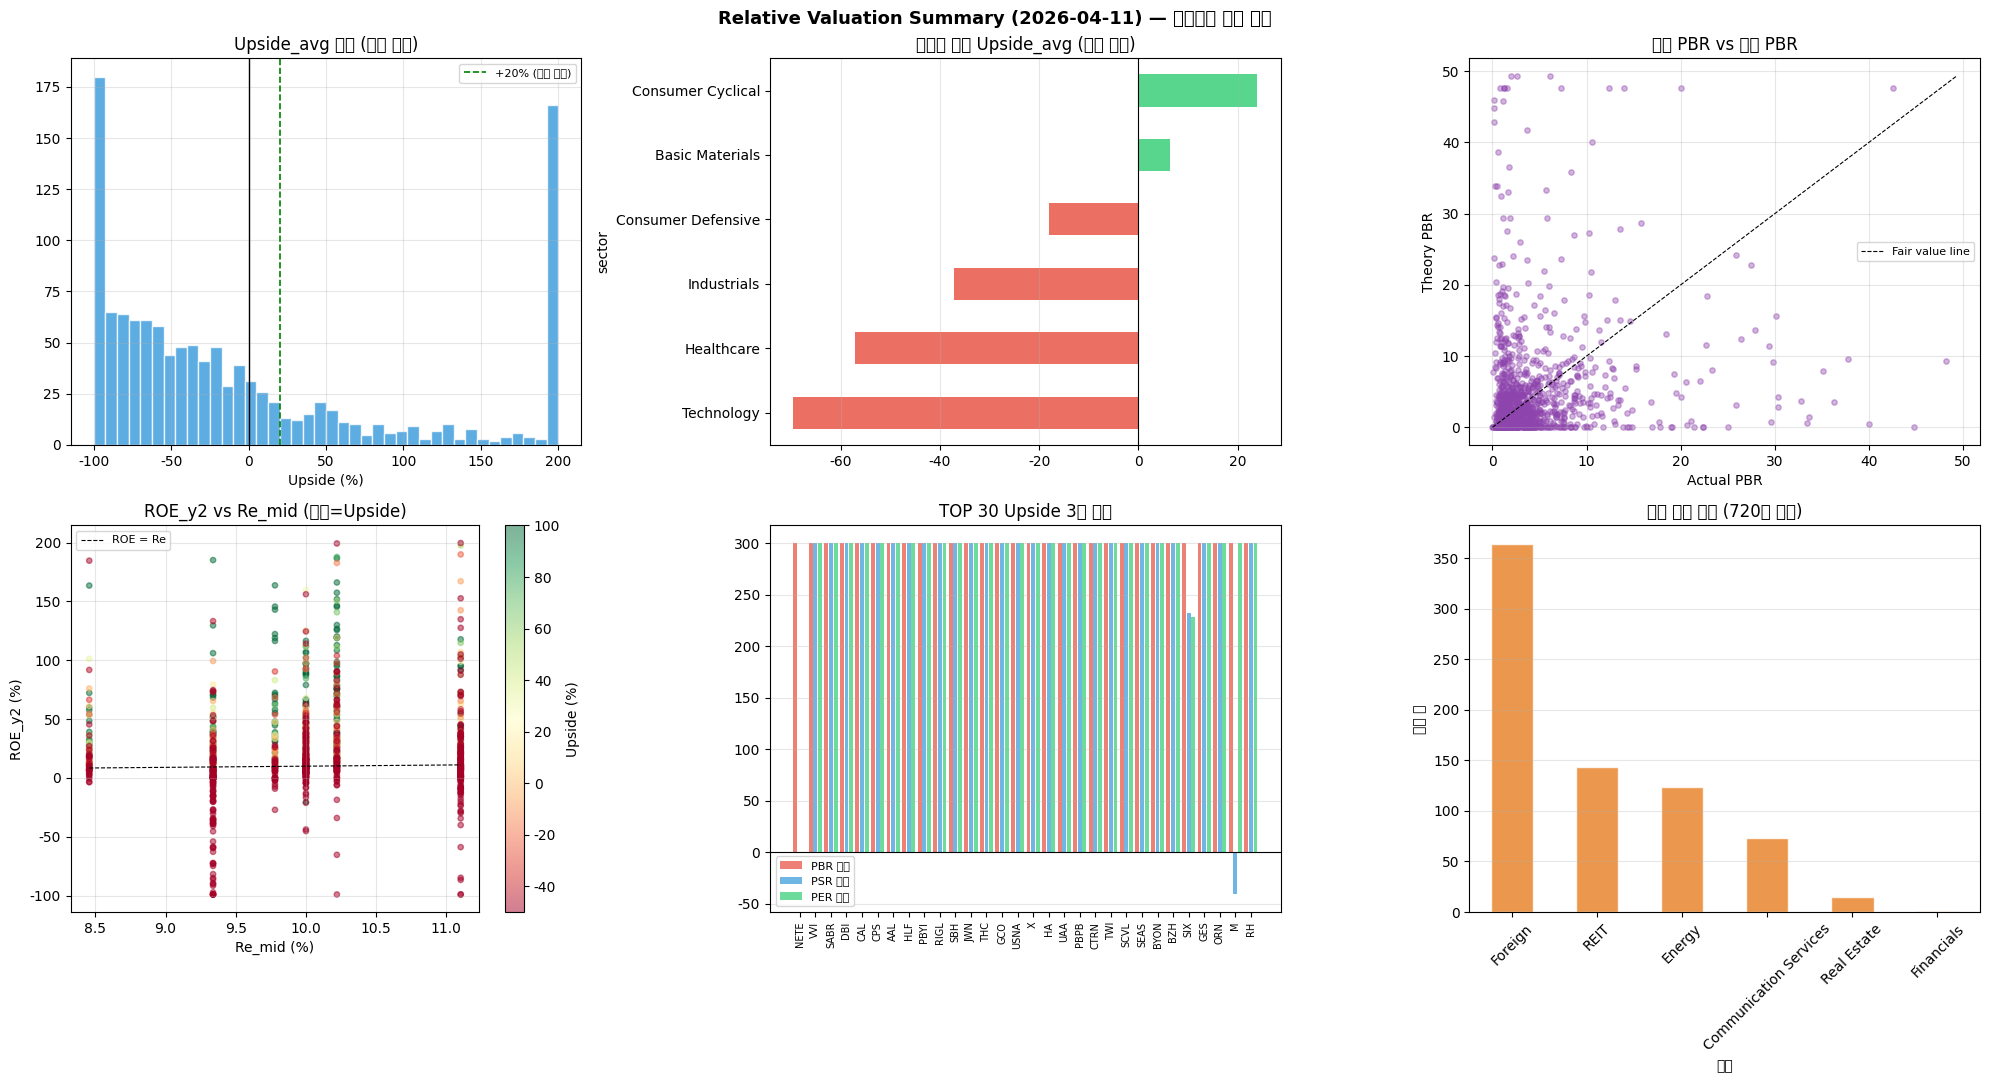

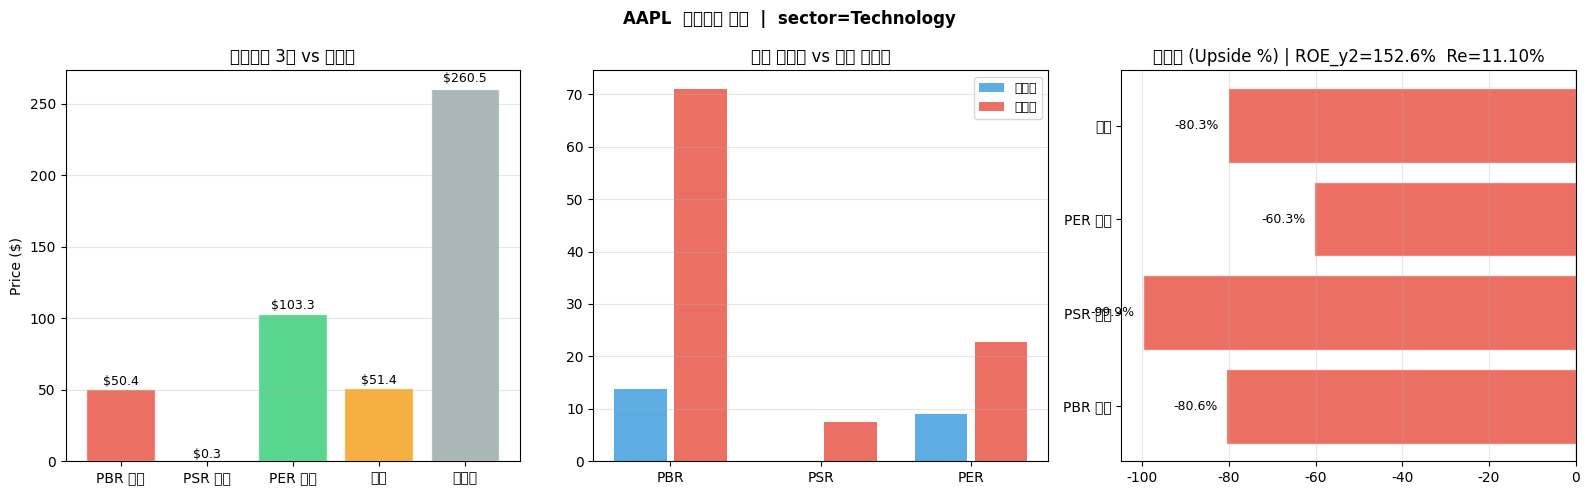

  [AAPL] sector=Technology  TP_avg=$51.37  Up_avg=-80.3%  PBR_th=13.75x  g=0.00%


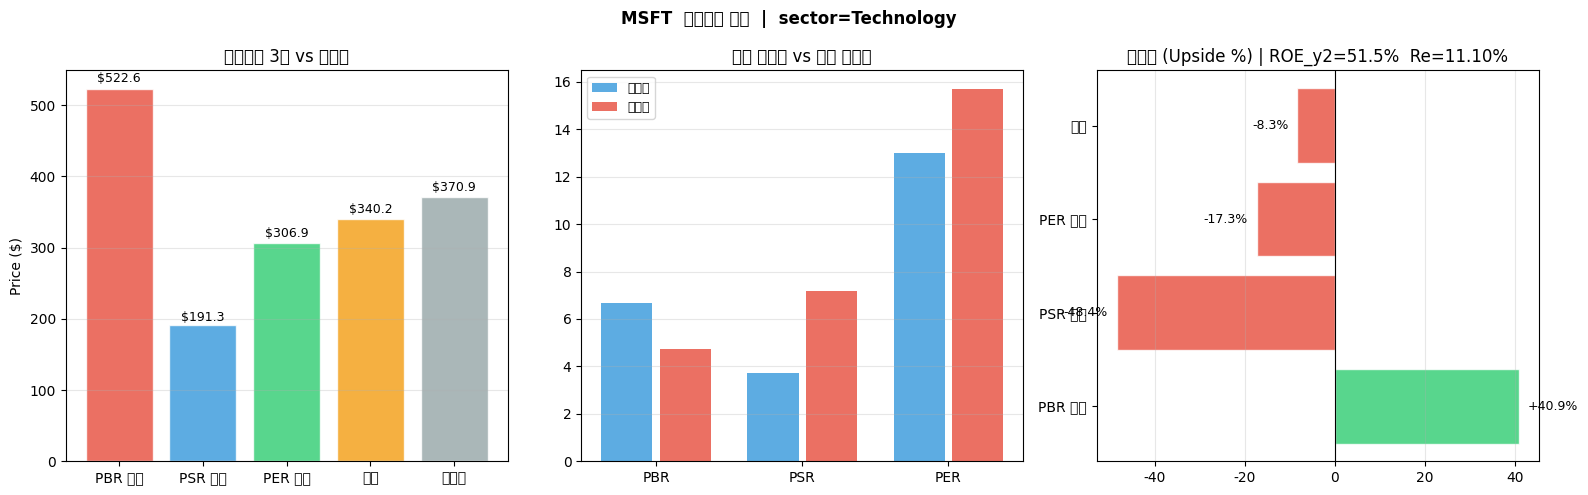

  [MSFT] sector=Technology  TP_avg=$340.24  Up_avg=-8.3%  PBR_th=6.69x  g=4.00%


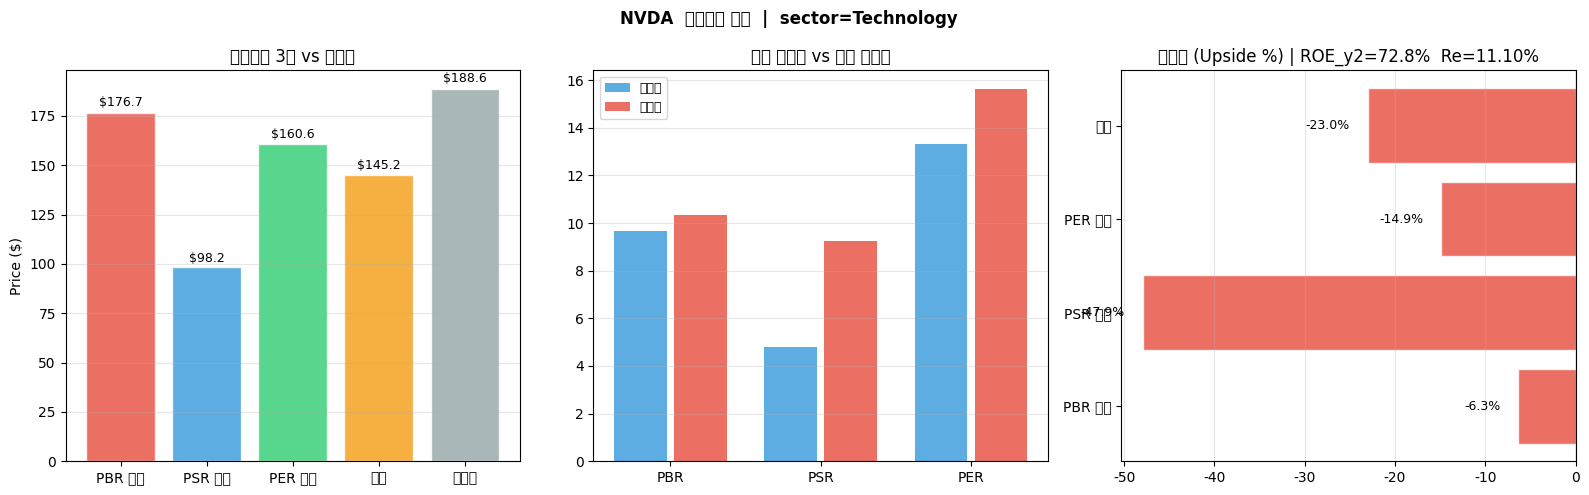

  [NVDA] sector=Technology  TP_avg=$145.17  Up_avg=-23.0%  PBR_th=9.68x  g=4.00%


In [8]:
# ─────────────────────────────────────────────────────────────────
# DB에서 최신 결과 조회 + 시각화 (제외 업종 필터 포함)
# ─────────────────────────────────────────────────────────────────

conn = get_conn()
try:
    with conn.cursor() as cur:
        cur.execute(f"SELECT MAX(date) AS max_date FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["max_date"]
        if max_date:
            cur.execute(f"""
                SELECT ticker, sector, is_excluded,
                       tp_pbr, tp_psr, tp_per, tp_avg,
                       upside_pbr, upside_psr, upside_per, upside_avg,
                       pbr_theory, psr_theory, per_theory,
                       actual_pbr, actual_psr, actual_per,
                       roe_y2, re_mid, g_est, beta_ensemble,
                       current_price
                FROM {TABLE_RESULT}
                WHERE date=%s AND tp_avg IS NOT NULL
                ORDER BY upside_avg DESC
            """, (max_date,))
            df_result = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

if max_date and not df_result.empty:
    df_incl = df_result[df_result["is_excluded"] == 0].copy()
    df_excl = df_result[df_result["is_excluded"] == 1].copy()

    print(f"[최신 실행일: {max_date}]  전체={len(df_result)}  포함={len(df_incl)}  제외={len(df_excl)}")

    # ── 통계 (포함 업종만) ──────────────────────────────────────
    print(f"\n[포함 업종 통계 — upside_avg]")
    print(df_incl["upside_avg"].describe().round(1).to_string())

    print(f"\n[포함 업종 TOP 30]")
    display(df_incl[["ticker","sector","tp_avg","upside_avg",
                      "pbr_theory","actual_pbr","roe_y2","re_mid"]].head(30))

    # ── 시각화 ─────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 3, figsize=(20, 11))
    fig.suptitle(f"Relative Valuation Summary ({max_date}) — 제외업종 필터 적용",
                 fontsize=13, fontweight="bold")

    # 1. Upside 분포 (포함 업종)
    ax = axes[0, 0]
    up_clean = df_incl["upside_avg"].dropna().clip(-100, 200)
    ax.hist(up_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0,  color="black", lw=1.0)
    ax.axvline(20, color="green", lw=1.2, ls="--", label="+20% (매수 후보)")
    ax.set_title("Upside_avg 분포 (포함 업종)"); ax.set_xlabel("Upside (%)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 2. 업종별 평균 Upside
    ax = axes[0, 1]
    sect_up = df_incl.groupby("sector")["upside_avg"].median().sort_values()
    colors  = ["#e74c3c" if x < 0 else "#2ecc71" for x in sect_up]
    sect_up.plot(kind="barh", ax=ax, color=colors, alpha=0.8)
    ax.axvline(0, color="black", lw=0.8)
    ax.set_title("업종별 중위 Upside_avg (포함 업종)"); ax.grid(axis="x", alpha=0.3)

    # 3. PBR theory vs actual
    ax = axes[0, 2]
    valid_pbr = df_incl[["pbr_theory","actual_pbr"]].dropna()
    valid_pbr = valid_pbr[(valid_pbr["pbr_theory"]<50) & (valid_pbr["actual_pbr"]<50)]
    ax.scatter(valid_pbr["actual_pbr"], valid_pbr["pbr_theory"],
               alpha=0.4, s=15, color="#8e44ad")
    lim = max(valid_pbr.max().max(), 1)
    ax.plot([0, lim], [0, lim], "k--", lw=0.8, label="Fair value line")
    ax.set_xlabel("Actual PBR"); ax.set_ylabel("Theory PBR")
    ax.set_title("이론 PBR vs 실제 PBR"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 4. ROE_y2 vs Re_mid 산점도
    ax = axes[1, 0]
    valid_re = df_incl[["roe_y2","re_mid","upside_avg"]].dropna()
    valid_re = valid_re[(valid_re["roe_y2"].abs()<2)]
    sc = ax.scatter(valid_re["re_mid"]*100, valid_re["roe_y2"]*100,
                    c=valid_re["upside_avg"].clip(-100,200),
                    cmap="RdYlGn", alpha=0.5, s=15, vmin=-50, vmax=100)
    plt.colorbar(sc, ax=ax, label="Upside (%)")
    lim_x = np.linspace(valid_re["re_mid"].min(), valid_re["re_mid"].max(), 50)*100
    ax.plot(lim_x, lim_x, "k--", lw=0.8, label="ROE = Re")
    ax.set_xlabel("Re_mid (%)"); ax.set_ylabel("ROE_y2 (%)")
    ax.set_title("ROE_y2 vs Re_mid (색상=Upside)"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 5. TP 3종 비교 (포함 업종 상위 30)
    ax = axes[1, 1]
    top30 = df_incl.head(30).set_index("ticker")
    x = range(len(top30))
    ax.bar([i-0.3 for i in x], top30["upside_pbr"].clip(-100,300), 0.25,
           label="PBR 기반", alpha=0.7, color="#e74c3c")
    ax.bar([i     for i in x], top30["upside_psr"].clip(-100,300), 0.25,
           label="PSR 기반", alpha=0.7, color="#3498db")
    ax.bar([i+0.3 for i in x], top30["upside_per"].clip(-100,300), 0.25,
           label="PER 기반", alpha=0.7, color="#2ecc71")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xticks(list(x)); ax.set_xticklabels(top30.index, rotation=90, fontsize=7)
    ax.set_title("TOP 30 Upside 3종 비교"); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

    # 6. 제외 업종 분포
    ax = axes[1, 2]
    if not df_excl.empty:
        excl_cnt_by_sect = df_excl["sector"].value_counts()
        excl_cnt_by_sect.plot(kind="bar", ax=ax, color="#e67e22", alpha=0.8, edgecolor="white")
        ax.set_title(f"제외 업종 분포 ({len(df_excl)}개 제외)")
        ax.set_xlabel("업종"); ax.set_ylabel("종목 수"); ax.tick_params(axis="x", rotation=45)
        ax.grid(axis="y", alpha=0.3)
    else:
        ax.text(0.5, 0.5, "제외 종목 없음", transform=ax.transAxes,
                ha="center", va="center", fontsize=12)

    plt.tight_layout()
    plt.show()

    # ── 개별 종목 시각화 ─────────────────────────────────────────
    VIZ_TICKERS = ["AAPL","MSFT","NVDA"]  # 변경 가능

    for tk in VIZ_TICKERS:
        row = df_result[df_result["ticker"]==tk]
        if row.empty: print(f"[{tk}] 데이터 없음"); continue
        r = row.iloc[0]

        fig2, axes2 = plt.subplots(1, 3, figsize=(16, 5))
        fig2.suptitle(f"{tk}  상대가치 평가  |  sector={r['sector']}  "
                      f"{'[제외 업종]' if r['is_excluded'] else ''}",
                      fontsize=12, fontweight="bold")

        # TP 3종 vs 현재가
        ax = axes2[0]
        cats    = ["PBR 기반","PSR 기반","PER 기반","평균","현재가"]
        vals    = [r["tp_pbr"],r["tp_psr"],r["tp_per"],r["tp_avg"],r["current_price"]]
        colors2 = ["#e74c3c","#3498db","#2ecc71","#f39c12","#95a5a6"]
        bars = ax.bar(cats, vals, color=colors2, alpha=0.8, edgecolor="white")
        for bar, val in zip(bars, vals):
            if not (isinstance(val, float) and np.isnan(val)):
                ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                        f"${val:.1f}", ha="center", va="bottom", fontsize=9)
        ax.set_title("적정주가 3종 vs 현재가"); ax.set_ylabel("Price ($)"); ax.grid(axis="y", alpha=0.3)

        # 이론 vs 실제 멀티플
        ax = axes2[1]
        mult_cats = ["PBR","PSR","PER"]
        theory_v  = [r["pbr_theory"],r["psr_theory"],r["per_theory"]]
        actual_v  = [r["actual_pbr"],r["actual_psr"],r["actual_per"]]
        x2 = range(3)
        ax.bar([i-0.2 for i in x2], theory_v, 0.35, label="이론값", color="#3498db", alpha=0.8)
        ax.bar([i+0.2 for i in x2], actual_v, 0.35, label="실제값", color="#e74c3c", alpha=0.8)
        ax.set_xticks(list(x2)); ax.set_xticklabels(mult_cats)
        ax.set_title("이론 멀티플 vs 실제 멀티플"); ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)

        # Upside 수평 바
        ax = axes2[2]
        up_cats = ["PBR 기반","PSR 기반","PER 기반","평균"]
        up_vals = [r["upside_pbr"],r["upside_psr"],r["upside_per"],r["upside_avg"]]
        up_clean2 = [v if (v is not None and not (isinstance(v,float) and np.isnan(v))) else 0 for v in up_vals]
        colors3 = ["#2ecc71" if v>=0 else "#e74c3c" for v in up_clean2]
        bars2 = ax.barh(up_cats, up_clean2, color=colors3, alpha=0.8, edgecolor="white")
        ax.axvline(0, color="black", lw=0.8)
        for bar, val in zip(bars2, up_clean2):
            ax.text(val + (2 if val>=0 else -2), bar.get_y()+bar.get_height()/2,
                    f"{val:+.1f}%", va="center", fontsize=9,
                    ha="left" if val>=0 else "right")
        ax.set_title(f"괴리율 (Upside %) | ROE_y2={r['roe_y2']:.1%}  Re={r['re_mid']:.2%}")
        ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()
        plt.show()
        print(f"  [{tk}] sector={r['sector']}  TP_avg=${r['tp_avg']:.2f}  "
              f"Up_avg={r['upside_avg']:.1f}%  PBR_th={r['pbr_theory']:.2f}x  "
              f"g={r['g_est']:.2%}")
